In [ ]:
!pip install "numpy==2.0.2" pennylane

In [ ]:
"""
evaluation_schemes.py

"""

import numpy as np
from sklearn.metrics import f1_score, hamming_loss, classification_report



def exact_match_scores(gold: np.ndarray, preds: np.ndarray) -> dict:
    
    assert gold.shape == preds.shape, "gold and preds must have the same shape"

    # Row-wise equality: True only when ALL labels in a row match
    row_matches = np.all(gold == preds, axis=1)          # (N,) bool
    emr = float(row_matches.mean())                      # Exact Match Ratio

    # For a strict binary decision (match vs. no-match):
    #   TP = matched samples, FP = 0, FN = 0  →  P = R = F1 = EMR
    return {
        "precision"         : emr,
        "recall"            : emr,
        "f1"                : emr,
        "exact_match_ratio" : emr,
        "num_exact_matches" : int(row_matches.sum()),
    }



def _instance_prf(gold_row: np.ndarray, pred_row: np.ndarray):
    
    gold_set = set(np.where(gold_row == 1)[0])
    pred_set = set(np.where(pred_row == 1)[0])

    # Both empty → perfect prediction
    if len(gold_set) == 0 and len(pred_set) == 0:
        return 1.0, 1.0, 1.0

    # One empty, the other not → zero overlap
    if len(gold_set) == 0 or len(pred_set) == 0:
        return 0.0, 0.0, 0.0

    overlap = len(gold_set & pred_set)
    precision = overlap / len(pred_set)
    recall    = overlap / len(gold_set)
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)
    return precision, recall, f1


def partial_match_scores(gold: np.ndarray, preds: np.ndarray) -> dict:
    
    assert gold.shape == preds.shape

    precisions, recalls, f1s = [], [], []
    for g_row, p_row in zip(gold, preds):
        p, r, f = _instance_prf(g_row, p_row)
        precisions.append(p)
        recalls.append(r)
        f1s.append(f)

    return {
        "precision" : float(np.mean(precisions)),
        "recall"    : float(np.mean(recalls)),
        "f1"        : float(np.mean(f1s)),
    }

def evaluate_all_schemes(
    gold: np.ndarray,
    preds: np.ndarray,
    label_names: list[str] | None = None,
    verbose: bool = True,
) -> dict:
    

    # ── Scheme 1 : Per-label sklearn metrics ──────────────────────────────────
    scheme1 = {
        "macro_f1"    : f1_score(gold, preds, average="macro",    zero_division=0),
        "micro_f1"    : f1_score(gold, preds, average="micro",    zero_division=0),
        "weighted_f1" : f1_score(gold, preds, average="weighted", zero_division=0),
        "hamming_loss": hamming_loss(gold, preds),
    }

    # ── Scheme 2 : Exact match ────────────────────────────────────────────────
    scheme2 = exact_match_scores(gold, preds)

    # ── Scheme 3 : Partial match ──────────────────────────────────────────────
    scheme3 = partial_match_scores(gold, preds)

    results = {"scheme1": scheme1, "scheme2": scheme2, "scheme3": scheme3}

    if verbose:
        _print_report(results, gold, preds, label_names)

    return results


def _print_report(results, gold, preds, label_names):
    sep = "=" * 62

    print(sep)
    print("  SCHEME 1 – Per-label sklearn metrics  (existing baseline)")
    print(sep)
    s1 = results["scheme1"]
    print(f"  Macro  F1      : {s1['macro_f1']:.4f}")
    print(f"  Micro  F1      : {s1['micro_f1']:.4f}")
    print(f"  Weighted F1    : {s1['weighted_f1']:.4f}")
    print(f"  Hamming Loss   : {s1['hamming_loss']:.4f}")
    if label_names:
        print("\n  Per-label classification report:")
        print(
            classification_report(
                gold, preds,
                target_names=label_names,
                digits=4,
                zero_division=0,
            )
        )

    print(sep)
    print("  SCHEME 2 – Exact Match")
    print(sep)
    s2 = results["scheme2"]
    print(f"  Exact Match Ratio (EMR) : {s2['exact_match_ratio']:.4f}")
    print(f"  Num Exact Matches       : {s2['num_exact_matches']}")
    print(f"  Precision               : {s2['precision']:.4f}")
    print(f"  Recall                  : {s2['recall']:.4f}")
    print(f"  F1                      : {s2['f1']:.4f}")
    print("  [Note: P = R = F1 = EMR for strict exact-match scoring]")

    print(sep)
    print("  SCHEME 3 – Partial Match  (instance-level set overlap)")
    print(sep)
    s3 = results["scheme3"]
    print(f"  Precision (macro-inst.) : {s3['precision']:.4f}")
    print(f"  Recall    (macro-inst.) : {s3['recall']:.4f}")
    print(f"  F1        (macro-inst.) : {s3['f1']:.4f}")
    print(sep)



if __name__ == "__main__":
    rng = np.random.default_rng(42)

    EMOTION_COLS = ["Love", "Joy", "Surprise", "Anger", "Sadness", "Fear"]

    # Simulate gold labels and predictions
    gold  = (rng.random((50, 6)) > 0.6).astype(int)
    preds = gold.copy()

    # Flip ~15 % of bits to simulate imperfect predictions
    flip_mask = rng.random((50, 6)) < 0.15
    preds[flip_mask] = 1 - preds[flip_mask]

    # --- Manual examples from the task description ---
    print("Manual example checks")
    print("-" * 40)

    g1 = np.array([[0, 0, 1, 1, 0, 1]])
    p1 = np.array([[0, 0, 1, 1, 0, 1]])   # perfect
    g2 = np.array([[0, 0, 1, 1, 0, 1]])
    p2 = np.array([[0, 0, 1, 1, 0, 0]])   # one label off

    print("Example 1 (perfect):")
    print(f"  Exact match score  : {exact_match_scores(g1, p1)['exact_match_ratio']}")
    print(f"  Partial match F1   : {partial_match_scores(g1, p1)['f1']:.4f}")

    print("Example 2 (one label off):")
    print(f"  Exact match score  : {exact_match_scores(g2, p2)['exact_match_ratio']}")
    print(f"  Partial match F1   : {partial_match_scores(g2, p2)['f1']:.4f}")

    print("\nFull 50-sample evaluation:")
    evaluate_all_schemes(gold, preds, label_names=EMOTION_COLS, verbose=True)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pennylane as qml

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, hamming_loss
)
from sklearn.utils.class_weight import compute_class_weight

from tqdm import tqdm
import pennylane as qml

try:
    from evaluation_schemes import evaluate_all_schemes
except ModuleNotFoundError:
    pass  # already defined by the pasted code cell above

In [ ]:
gpu_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cpu_device = torch.device("cpu")

print("GPU device:", gpu_device)
print("CPU device:", cpu_device)

In [ ]:
def set_seed(seed_value=42):
    """Set seeds for reproducibility across PyTorch, NumPy, and Python."""
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

In [ ]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith('.csv'):
            print(os.path.join(root, f))

In [ ]:
import glob
csv_files = glob.glob('/kaggle/input/**/Train.csv', recursive=True)
print('Found:', csv_files)
assert len(csv_files) >= 1, 'No Train.csv found under /kaggle/input'
base = csv_files[0].rsplit('/', 1)[0]

df_tr = pd.read_csv(f'{base}/Train.csv')
df_vl = pd.read_csv(f'{base}/Val.csv')
df_te = pd.read_csv(f'{base}/Test.csv')
# Reset indices for safe iloc access in Dataset
df_tr = df_tr.reset_index(drop=True)
df_vl = df_vl.reset_index(drop=True)
df_te = df_te.reset_index(drop=True)

print("Train:", df_tr.shape, "| Valid:", df_vl.shape, "| Test:", df_te.shape)
df_tr.head()


In [ ]:
EMOTION_COLS = ['Love', 'Joy', 'Surprise', 'Anger', 'Sadness', 'Fear']
TEXT_COL     = 'Data'
NUM_LABELS   = len(EMOTION_COLS)

for split_name, split_df in [('Train', df_tr), ('Valid', df_vl), ('Test', df_te)]:
    assert TEXT_COL in split_df.columns, f"{split_name}: missing column '{TEXT_COL}'"
    assert all(c in split_df.columns for c in EMOTION_COLS), \
        f"{split_name}: missing emotion columns"

print(f"NUM_LABELS = {NUM_LABELS}  →  {EMOTION_COLS}")
print("\nTrain label distribution:")
print(df_tr[EMOTION_COLS].sum().sort_values(ascending=False))

In [ ]:
class EmoNoBaDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.data      = df
        self.tokenizer = tokenizer
        self.max_len   = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        encoding = self.tokenizer(
            str(row[TEXT_COL]),
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        label = torch.tensor(
            row[EMOTION_COLS].values.astype(np.float32),
            dtype=torch.float32
        )

        return (
            encoding['input_ids'].squeeze(0),       # (max_length,)
            encoding['attention_mask'].squeeze(0),  # (max_length,)
            label                                   # (NUM_LABELS,)
        )

In [ ]:
TEXT_MODEL   = 'ai4bharat/IndicBERTv2-MLM-only'

tokenizer    = AutoTokenizer.from_pretrained(TEXT_MODEL)
text_encoder = AutoModel.from_pretrained(TEXT_MODEL).to(gpu_device)

print("Text encoder loaded on:", next(text_encoder.parameters()).device)

0: ──RX(0.00)──RY(0.00)──Rot(0.00,0.00,0.00)─╭●───────────────────╭Z──RX(0.00)──RY(0.00) ···
1: ──RX(0.00)──RY(0.00)──Rot(0.00,0.00,0.00)─╰Z─╭●────────────────│───RX(0.00)──RY(0.00) ···
2: ──RX(0.00)──RY(0.00)──Rot(0.00,0.00,0.00)────╰Z─╭●─────────────│───RX(0.00)──RY(0.00) ···
3: ──RX(0.00)──RY(0.00)──Rot(0.00,0.00,0.00)───────╰Z─╭●──────────│───RX(0.00)──RY(0.00) ···
4: ──RX(0.00)──RY(0.00)──Rot(0.00,0.00,0.00)──────────╰Z─╭●───────│───RX(0.00)──RY(0.00) ···
5: ──RX(0.00)──RY(0.00)──Rot(0.00,0.00,0.00)─────────────╰Z─╭●────│───RX(0.00)──RY(0.00) ···
6: ──RX(0.00)──RY(0.00)──Rot(0.00,0.00,0.00)────────────────╰Z─╭●─│───RX(0.00)──RY(0.00) ···
7: ──RX(0.00)──RY(0.00)──Rot(0.00,0.00,0.00)───────────────────╰Z─╰●──RX(0.00)──RY(0.00) ···

0: ··· ──Rot(0.00,0.00,0.00)─╭●───────────────────╭Z─┤  <Z>
1: ··· ──Rot(0.00,0.00,0.00)─╰Z─╭●────────────────│──┤  <Z>
2: ··· ──Rot(0.00,0.00,0.00)────╰Z─╭●─────────────│──┤  <Z>
3: ··· ──Rot(0.00,0.00,0.00)───────╰Z─╭●──────────│──┤  <Z>
4: ··· ──Rot(0.

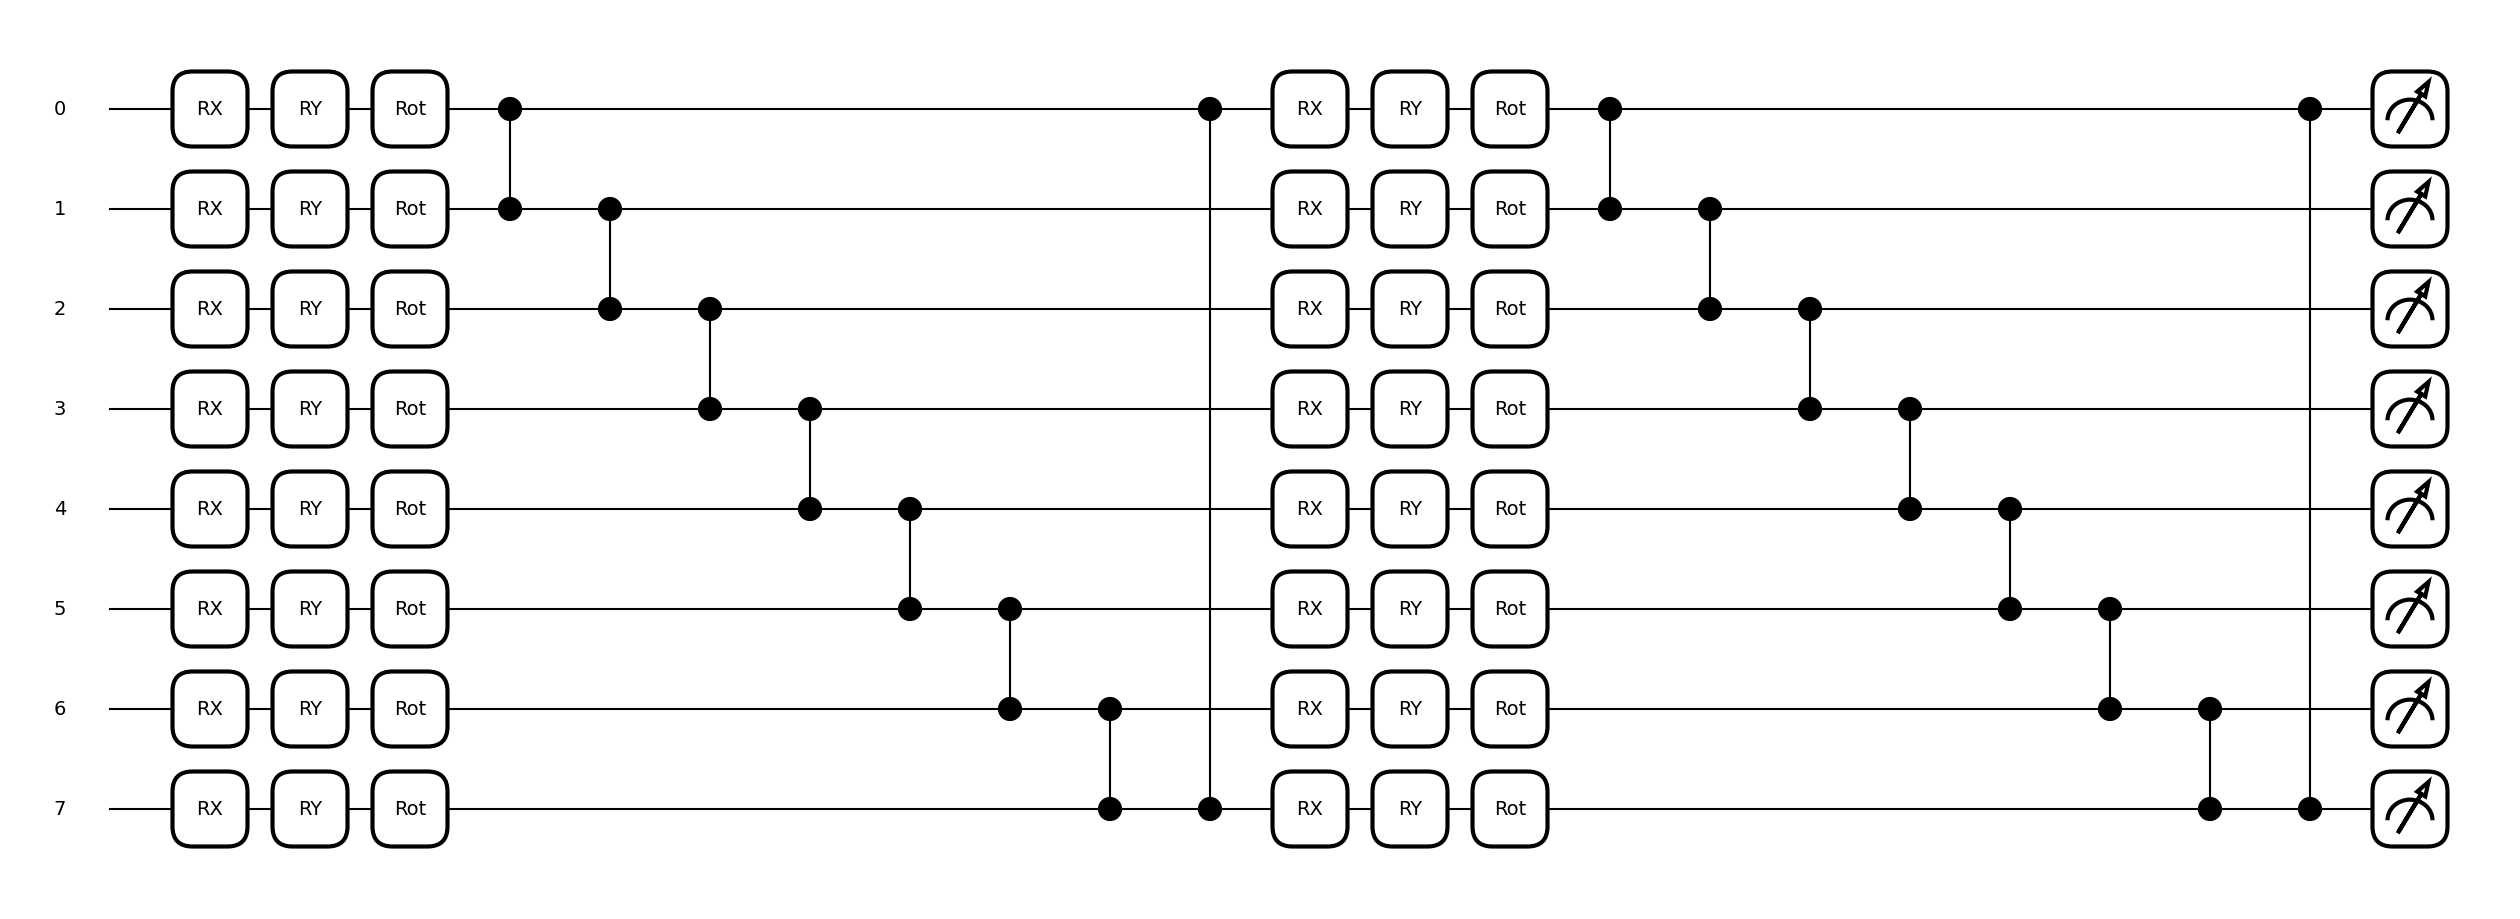

In [ ]:
"""

ADD YOUR VQC HERE ...

"""

import torch
import torch.nn as nn
import pennylane as qml
import matplotlib.pyplot as plt 

N_QUBITS   = 8
N_Q_LAYERS = 1

dev = qml.device("default.qubit", wires=N_QUBITS)

# Trainable parameters live inside a module so they follow model.to(device)
class VQCParams(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_phi   = nn.Parameter(torch.zeros(N_QUBITS))
        self.input_scale = nn.Parameter(torch.full((N_QUBITS,), 0.5))
        self.weights     = nn.Parameter(torch.randn(N_Q_LAYERS, N_QUBITS, 3) * 0.1)

_vqc_params = VQCParams()  # will be moved to gpu_device after the model is created

INPUT_PHI   = _vqc_params.input_phi
INPUT_SCALE = _vqc_params.input_scale
WEIGHTS     = _vqc_params.weights


#1. ENCODING 
def encode(inputs):
    """Put the 16-d input vector into 8 qubits (2 rotations per qubit)."""
    for q in range(N_QUBITS):
        c, s = torch.cos(INPUT_PHI[q]), torch.sin(INPUT_PHI[q])
        i0 = 2 * q
        i1 = 2 * q + 1
        # mix each qubit's own feature pair using a learnable phase
        x_rx = INPUT_SCALE[q] * (c * inputs[i0] - s * inputs[i1])
        x_ry = INPUT_SCALE[q] * (s * inputs[i0] + c * inputs[i1])
        qml.RX(x_rx, wires=q)
        qml.RY(x_ry, wires=q)


# 2. ANSATZ
def ansatz_block(w):
    """Trainable Rot on every qubit + a ring of CZ gates."""
    for q in range(N_QUBITS):
        qml.Rot(w[q, 0], w[q, 1], w[q, 2], wires=q)
    for q in range(N_QUBITS):
        qml.CZ(wires=[q, (q + 1) % N_QUBITS])


#3. FULL CIRCUIT
@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    # encode -> ansatz -> re-encode -> ansatz (data re-uploading)
    encode(inputs)
    ansatz_block(weights)
    encode(inputs)
    ansatz_block(weights)
    # 4. MEASUREMENT: 16 expectation values (Z + X per qubit)
    return [qml.expval(qml.PauliZ(q)) for q in range(N_QUBITS)] + [qml.expval(qml.PauliX(q)) for q in range(N_QUBITS)]


#5. RUN THE CIRCUIT
def run(x_batch):
    """x_batch: tensor of shape (B, N_QUBITS) -> (B, N_QUBITS) expectations."""
    out = []
    for sample in x_batch:
        out.append(torch.stack(quantum_circuit(sample, WEIGHTS.squeeze(0))))
    return torch.stack(out)

quantum_params = nn.ParameterList([INPUT_PHI, INPUT_SCALE, WEIGHTS])

def run_batch(x_batch):
    """x_batch: tensor (B, N_QUBITS) -> tensor (B, N_QUBITS) expectations."""
    out = []
    for sample in x_batch:
        out.append(torch.stack(quantum_circuit(sample, WEIGHTS[0])))   # ← slice
    return torch.stack(out)

# 6. CIRCUIT PREVIEW
dummy_inputs  = torch.zeros(2 * N_QUBITS)
dummy_weights = torch.zeros(N_Q_LAYERS, N_QUBITS, 3).squeeze(0)  # (8, 3)
print(qml.draw(quantum_circuit)(dummy_inputs, dummy_weights))

fig, ax = qml.draw_mpl(quantum_circuit)(dummy_inputs, dummy_weights)
plt.show()




In [ ]:
class QuantumBottleneck(nn.Module):
    def __init__(self):
        super().__init__()
        # Use module-level tensors so all params get optimized by AdamW
        self.weights     = WEIGHTS          # alias to the nn.Parameter we defined above
        self.input_phi   = INPUT_PHI
        self.input_scale = INPUT_SCALE

    def forward(self, x):
        outputs = []
        for i in range(x.shape[0]):
            out = torch.stack(quantum_circuit(x[i], self.weights[0]))   # ← slice
            outputs.append(out)
        return torch.stack(outputs)

In [ ]:
class QuantumFusionLayer(nn.Module):
    def __init__(self, in_dim=128, q_dim=8):
        super().__init__()
        assert q_dim == N_QUBITS, "q_dim must match N_QUBITS"

        self.pre_q   = nn.Linear(in_dim, 2 * q_dim)
        self.quantum = QuantumBottleneck()
        self.post_q  = nn.Linear(2 * q_dim, in_dim)

    def forward(self, x):
        x_q   = torch.tanh(self.pre_q(x))
        q_out = self.quantum(x_q.to(cpu_device))
        return self.post_q(q_out.to(x.device).to(x.dtype))


In [ ]:
class QuantumEmotionClassifier(nn.Module):
    def __init__(self, num_labels):
        super().__init__()

        self.text_encoder = text_encoder

        self.text_compressed = nn.Sequential(
            nn.Linear(768, 128),
        )

        self.quantum_fusion = QuantumFusionLayer(in_dim=128, q_dim=N_QUBITS)

        self.classifier = nn.Linear(128, num_labels)

    def forward(self, input_ids, attention_mask):
        text_feat = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state[:, 0, :]                       

        text_compressed = self.text_compressed(text_feat)       

        q_out  = self.quantum_fusion(text_compressed)  

        return self.classifier(F.relu(q_out))            

In [ ]:
MAX_LEN    = 128
BATCH_SIZE = 8

train_dataset = EmoNoBaDataset(df_tr, tokenizer, MAX_LEN)
val_dataset   = EmoNoBaDataset(df_vl, tokenizer, MAX_LEN)
test_dataset  = EmoNoBaDataset(df_te, tokenizer, MAX_LEN)


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(42)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    worker_init_fn=seed_worker, generator=g
)
val_loader   = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    worker_init_fn=seed_worker, generator=g
)
test_loader  = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    worker_init_fn=seed_worker, generator=g
)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

In [ ]:
label_counts = df_tr[EMOTION_COLS].sum().values
total        = len(df_tr)
pos_weight   = torch.tensor(
    (total - label_counts) / np.clip(label_counts, 1, None),
    dtype=torch.float32
).to(gpu_device)

print("Per-label pos_weight:")
for col, w in zip(EMOTION_COLS, pos_weight.cpu().numpy()):
    print(f"  {col:<12}: {w:.3f}")

In [ ]:
def train_epoch(model, dataloader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    all_preds, all_gold = [], []

    for input_ids, attn_mask, labels in tqdm(dataloader, desc='Training'):
        input_ids = input_ids.to(gpu_device)
        attn_mask = attn_mask.to(gpu_device)
        labels    = labels.to(gpu_device)       # (B, NUM_LABELS) float32

        optimizer.zero_grad()
        logits = model(input_ids, attn_mask)    # (B, NUM_LABELS)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = (torch.sigmoid(logits) > 0.5).detach().cpu().numpy().astype(int)
        all_preds.append(preds)
        all_gold.append(labels.detach().cpu().numpy().astype(int))

    all_preds = np.vstack(all_preds)
    all_gold  = np.vstack(all_gold)
    macro_f1  = f1_score(all_gold, all_preds, average='macro', zero_division=0)

    return total_loss / len(dataloader), macro_f1

In [ ]:
def evaluate(model, dataloader, criterion, threshold=0.5):
    model.eval()
    total_loss = 0.0
    all_preds, all_gold = [], []

    with torch.no_grad():
        for input_ids, attn_mask, labels in dataloader:
            input_ids = input_ids.to(gpu_device)
            attn_mask = attn_mask.to(gpu_device)
            labels    = labels.to(gpu_device)

            logits = model(input_ids, attn_mask)
            loss   = criterion(logits, labels)
            total_loss += loss.item()

            preds = (torch.sigmoid(logits) > threshold).cpu().numpy().astype(int)
            all_preds.append(preds)
            all_gold.append(labels.cpu().numpy().astype(int))

    all_preds = np.vstack(all_preds)
    all_gold  = np.vstack(all_gold)

    # ── existing metrics ──────────────────────────────────────
    base_metrics = {
        'loss'         : total_loss / len(dataloader),
        'macro_f1'     : f1_score(all_gold, all_preds, average='macro',    zero_division=0),
        'micro_f1'     : f1_score(all_gold, all_preds, average='micro',    zero_division=0),
        'weighted_f1'  : f1_score(all_gold, all_preds, average='weighted', zero_division=0),
        'hamming_loss' : hamming_loss(all_gold, all_preds),
        'preds'        : all_preds,
        'gold'         : all_gold,
    }

    # ── new schemes (Exact Match + Partial Match) ─────────────
    extended = evaluate_all_schemes(
        gold        = all_gold,
        preds       = all_preds,
        label_names = EMOTION_COLS,
        verbose     = False,         # set True to auto-print on every call
    )
    base_metrics['exact_match']   = extended['scheme2']
    base_metrics['partial_match'] = extended['scheme3']

    return base_metrics

In [ ]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_score = None
        self.counter    = 0
        self.best_state = None

    def step(self, score, model):
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter    = 0
            self.best_state = {
                k: v.detach().cpu() for k, v in model.state_dict().items()
            }
            return False   # do NOT stop
        else:
            self.counter += 1
            return self.counter >= self.patience

    def restore(self, model):
        model.load_state_dict(self.best_state)

In [ ]:
model = QuantumEmotionClassifier(num_labels=NUM_LABELS).to(gpu_device)
_vqc_params.to(cpu_device)   # sync VQC params with the model device

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay = 0.01)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6
)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

early_stopping = EarlyStopping(patience=5)

print("Model on:", next(model.parameters()).device)
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,} | Trainable: {trainable_params:,}")

In [ ]:
# ============================================================
#  VQC TIME CALCULATOR (non-invasive: forward hooks only,
#  no changes to any existing model logic)
#  Accumulates wall-clock of every QuantumBottleneck.forward
#  call during training / validation / test.
# ============================================================
import time

_vqc_timer = {'total': 0.0, 'calls': 0, 't0': None}

def _vqc_pre_hook(module, args):
    _vqc_timer['t0'] = time.perf_counter()

def _vqc_post_hook(module, args, output):
    _vqc_timer['total'] += time.perf_counter() - _vqc_timer['t0']
    _vqc_timer['calls'] += 1

# remove old handles if this cell is re-run (avoids double counting)
try:
    _vqc_handle_pre.remove()
    _vqc_handle_post.remove()
except Exception:
    pass

_vqc_handle_pre  = model.quantum_fusion.quantum.register_forward_pre_hook(_vqc_pre_hook)
_vqc_handle_post = model.quantum_fusion.quantum.register_forward_hook(_vqc_post_hook)

print("VQC timer armed: total time and call count will accumulate during training.")

In [ ]:
NUM_EPOCHS = 25

train_loss_arr = []
val_loss_arr   = []
val_f1_arr     = []

for epoch in range(NUM_EPOCHS):
    train_loss, train_f1 = train_epoch(model, train_loader, optimizer, criterion)
    val_metrics          = evaluate(model, val_loader, criterion)

    val_loss = val_metrics['loss']
    val_f1   = val_metrics['macro_f1']

    scheduler.step(val_loss)

    print(
        f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | Train Macro-F1: {train_f1:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Macro-F1: {val_f1:.4f} | "
        f"Val Micro-F1: {val_metrics['micro_f1']:.4f} | "
    )

    train_loss_arr.append(train_loss)
    val_loss_arr.append(val_loss)
    val_f1_arr.append(val_f1)

    if early_stopping.step(val_f1, model):
        print(f"Early stopping triggered at epoch {epoch+1}.")
        break

In [ ]:
early_stopping.restore(model)
print(f"Best Val Macro-F1: {early_stopping.best_score:.4f}")

In [ ]:
# ============================================================
#  SAVE THE TRAINED MODEL (best weights from early stopping)
#  Saves to /kaggle/working (the only writable dir on Kaggle),
#  then copies it to the working root for easy download.
# ============================================================
import os, shutil

os.makedirs("saved_model", exist_ok=True)
ckpt_path = "saved_model/custom2_8q_indicbertv2_best.pt"

# best weights (includes IndicBERTv2 encoder + VQC params + heads)
torch.save(model.state_dict(), ckpt_path)

# also drop a copy at the working root so it's easy to find in Output
if os.getcwd() == "/kaggle/working":
    shutil.copy(ckpt_path, os.path.join(os.getcwd(), os.path.basename(ckpt_path)))

print("Model saved →", os.path.abspath(ckpt_path))
if os.path.exists(ckpt_path):
    print(f"Checkpoint size: {os.path.getsize(ckpt_path)/1e6:.1f} MB")
print("(On Kaggle this is /kaggle/working — download it from the Output tab before the session ends.)")

In [ ]:
test_metrics = evaluate(model, test_loader, criterion)

# Existing metrics
print(f"Test Loss        : {test_metrics['loss']:.4f}")
print(f"Test Macro-F1    : {test_metrics['macro_f1']:.4f}")
print(f"Test Micro-F1    : {test_metrics['micro_f1']:.4f}")
print(f"Test Weighted-F1 : {test_metrics['weighted_f1']:.4f}")
print(f"Test Hamming Loss: {test_metrics['hamming_loss']:.4f}")

# ── Scheme 2 : Exact Match ────────────────────────────────────
em = test_metrics['exact_match']
print(f"\n── Exact Match ──────────────────────────────")
print(f"  Exact Match Ratio : {em['exact_match_ratio']:.4f}")
print(f"  Precision         : {em['precision']:.4f}")
print(f"  Recall            : {em['recall']:.4f}")
print(f"  F1                : {em['f1']:.4f}")

# ── Scheme 3 : Partial Match ──────────────────────────────────
pm = test_metrics['partial_match']
print(f"\n── Partial Match (instance-level) ───────────")
print(f"  Precision         : {pm['precision']:.4f}")
print(f"  Recall            : {pm['recall']:.4f}")
print(f"  F1                : {pm['f1']:.4f}")

# Per-label report (unchanged)
print("\nPer-label Classification Report:")
print(classification_report(
    test_metrics['gold'], test_metrics['preds'],
    target_names=EMOTION_COLS, digits=4, zero_division=0
))

In [ ]:
# ============================================================
#  VQC TIME REPORT (run after the test scores above)
#  Shows the total time spent inside the VQC during the whole
#  training run, alongside the evaluation scores.
# ============================================================
vqc_total_s = _vqc_timer['total']
vqc_calls   = _vqc_timer['calls']

print("\n── VQC TIMING (measured live during training) ──────────")
print(f"  Total VQC time  : {vqc_total_s:.1f} s ({vqc_total_s/60:.2f} min)")
print(f"  Forward calls   : {vqc_calls}")
if vqc_calls > 0:
    print(f"  Per batch (B=8) : {vqc_total_s*1e3/vqc_calls:.2f} ms")
    print(f"  Per sample      : {vqc_total_s*1e3/vqc_calls/BATCH_SIZE:.2f} ms")

In [ ]:
# os.makedirs('./Preds', exist_ok=True)

# df_out = df_te.copy()
# for i, emotion in enumerate(EMOTION_COLS):
#     df_out[f'{emotion}_pred'] = conf_preds[:, i]

# df_out.to_excel('./Preds/qt_4qb_emoba_indicbertv2.xlsx', index=False)
# print("Predictions saved.")